## Latihan Praktikum

#### Load GDrive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Load Dataset

In [2]:
import os

data_dir = '/content/drive/My Drive/Colab Notebooks/Dataset'

# Check if the directory exists
if not os.path.exists(data_dir):
    print(f"Error: Directory '{data_dir}' not found.")
else:
    # Iterate through files and print their full paths
    file_paths = []
    for filename in os.listdir(data_dir):
        full_path = os.path.join(data_dir, filename)
        if os.path.isfile(full_path):
            print(full_path)
            file_paths.append(full_path)

/content/drive/My Drive/Colab Notebooks/Dataset/DATA RUMAH.xlsx
/content/drive/My Drive/Colab Notebooks/Dataset/Meta Data - Harga Rumah Jaksel.txt
/content/drive/My Drive/Colab Notebooks/Dataset/HARGA RUMAH JAKSEL.xlsx
/content/drive/My Drive/Colab Notebooks/Dataset/Meta Data - Data Rumah.txt
/content/drive/My Drive/Colab Notebooks/Dataset/healthy_dataset.csv
/content/drive/My Drive/Colab Notebooks/Dataset/hujan_dataset.csv
/content/drive/My Drive/Colab Notebooks/Dataset/HASIL_CLUSTER_DBSCAN.xlsx
/content/drive/My Drive/Colab Notebooks/Dataset/HASIL_CLUSTER_DIVISIVE.xlsx
/content/drive/My Drive/Colab Notebooks/Dataset/HASIL_CLUSTER_DIVISIVE_DENDROGRAM.xlsx
/content/drive/My Drive/Colab Notebooks/Dataset/HASIL_CLUSTER_GMM.xlsx
/content/drive/My Drive/Colab Notebooks/Dataset/kalimat_clustering.csv
/content/drive/My Drive/Colab Notebooks/Dataset/Data_Berita_Detik.csv


#### Load File berdasarkan Index

In [3]:
import pandas as pd

file_healthy = "/content/drive/My Drive/Colab Notebooks/Dataset/healthy_dataset.csv"
file_hujan = "/content/drive/My Drive/Colab Notebooks/Dataset/hujan_dataset.csv"

data_healthy = pd.read_csv(file_healthy)
data_hujan = pd.read_csv(file_hujan)

#### Menampilkan dataset

In [4]:
data_hujan

,Humidity,Temperature,Rain
0,85,22,1
1,90,24,1
2,78,23,1
3,60,30,0
4,55,33,0
5,88,21,1
6,95,20,1
7,45,35,0
8,50,32,0
9,72,25,1


#### Membuat model perceptron tanpa library

In [5]:
# prompt: create single perceptron code for data_hujan without library, save

import matplotlib.pyplot as plt

# Data preprocessing (assuming 'hujan' column is the target variable)
X = data_hujan[['Humidity', 'Temperature']].values # Features
y = data_hujan['Rain'].values # Target variable

# Initialize weights and bias
w = [0.1, 0.1]
b = 0.1
learning_rate = 0.0001
epochs = 30
errors = []

# Perceptron training
for epoch in range(epochs):
    total_error = 0
    for i in range(len(X)):
        # Calculate weighted sum
        z = w[0] * X[i][0] + w[1] * X[i][1] + b

        # Activation function (step function)
        prediction = 1 if z >= 0 else 0

        # Calculate error
        error = y[i] - prediction
        total_error += abs(error)

        # Update weights and bias
        w[0] += learning_rate * error * X[i][0]
        w[1] += learning_rate * error * X[i][1]
        b += learning_rate * error

    errors.append(total_error)

#### Menampilkan chart error

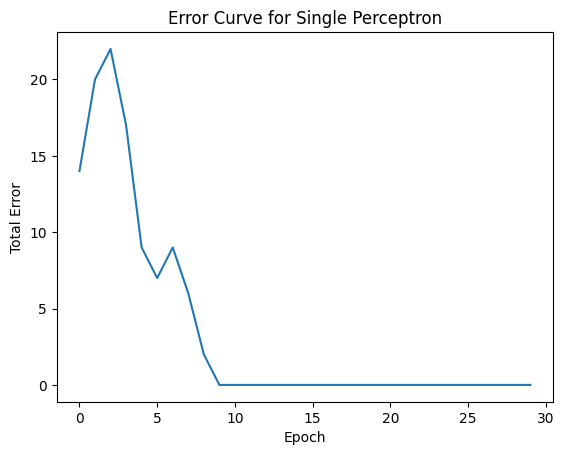

In [6]:
# Plot the error curve
plt.plot(range(epochs), errors)
plt.xlabel("Epoch")
plt.ylabel("Total Error")
plt.title("Error Curve for Single Perceptron")
plt.show()

#### Testing dengan data baru

In [7]:
import numpy as np

# Testing (example)
test_data = np.array([70, 25]) # Example test data
linear_output = np.dot(test_data, w) + b
prediction = 1 if linear_output >= 0 else 0

print(f"Prediction for input {test_data}: {prediction}")

Prediction for input [70 25]: 1


#### Membuat model perceptron dengan library keras

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Load the dataset (assuming it's already loaded into data_hujan)

# Data preprocessing (assuming 'hujan' column is the target variable)
X = data_hujan[['Humidity', 'Temperature']].values  # Features
y = data_hujan['Rain'].values  # Target variable

# Normalize the data
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# Define the perceptron model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(2,))
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X, y, epochs=100, verbose=0) # Set verbose to 0 to suppress output

# Evaluate the model
loss, accuracy = model.evaluate(X, y, verbose=0)
print(f"Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Loss: 0.6016, Accuracy: 0.9000


#### Menampilkan Plot error

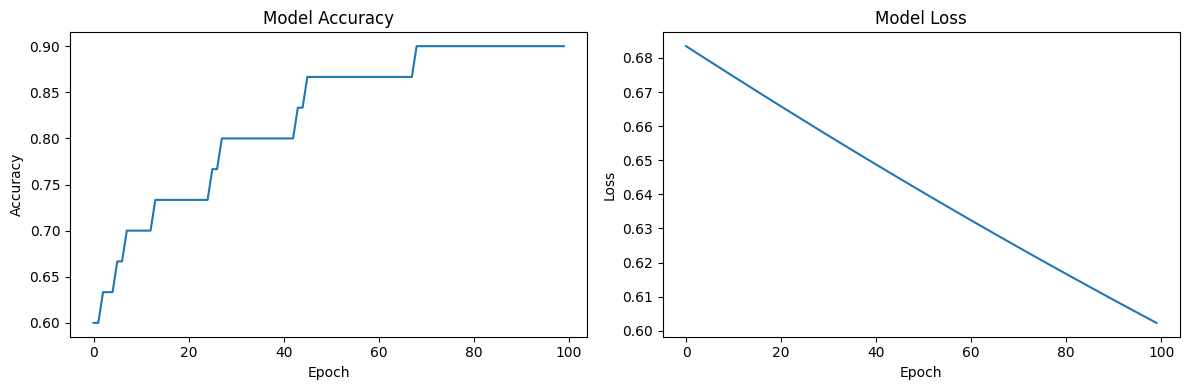

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
Prediction for input [[70 25]]: 1
Weights: [[0.40255433]
 [0.18127313]]
Bias: [0.08433259]


In [9]:
# Plot the training history
plt.figure(figsize=(12, 4))  # Adjust figure size

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

# Make predictions
test_data = np.array([[70, 25]])
test_data_normalized = (test_data - np.mean(X, axis=0)) / np.std(X, axis=0)
predictions = model.predict(test_data_normalized)
predicted_class = (predictions > 0.5).astype(int)

print(f"Prediction for input {test_data}: {predicted_class[0][0]}")

# Get model weights and bias
weights = model.layers[0].get_weights()[0]
bias = model.layers[0].get_weights()[1]
print("Weights:", weights)
print("Bias:", bias)

## Tugas Praktikum

#### 1. Lakukan eksperimen dengan dataset healthy tanpa libary dan dengan library

Tanpa Library

Training Manual Selesai.


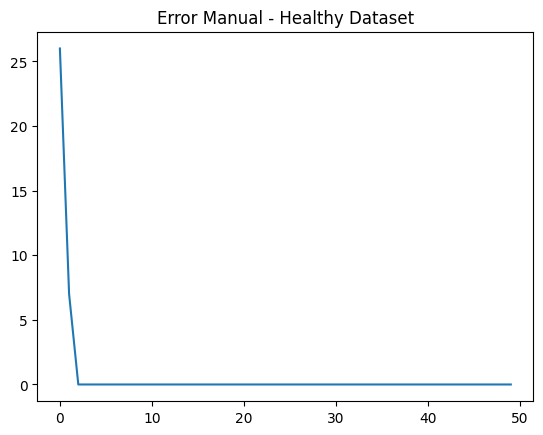

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data
file_healthy = "/content/drive/MyDrive/Colab Notebooks/Dataset/healthy_dataset.csv"
data_healthy = pd.read_csv(file_healthy)

# 2. Preprocessing (Sesuaikan nama kolom dengan file CSV kamu)
# Misal fitur: 'Feature1', 'Feature2' dan target: 'Status'
X = data_healthy.iloc[:, :-1].values # Mengambil semua kolom kecuali terakhir
y = data_healthy.iloc[:, -1].values  # Mengambil kolom terakhir sebagai target

# 3. Inisialisasi
w = [0.1] * X.shape[1]
b = 0.1
lr = 0.01
epochs = 50
errors_manual = []

# 4. Training Loop
for epoch in range(epochs):
    total_error = 0
    for i in range(len(X)):
        # Dot product manual: z = (w1*x1 + w2*x2 + ...) + b
        z = sum(w[j] * X[i][j] for j in range(len(w))) + b

        # Aktivasi Step Function
        pred = 1 if z >= 0 else 0

        # Hitung Error
        error = y[i] - pred
        total_error += abs(error)

        # Update Bobot & Bias
        for j in range(len(w)):
            w[j] += lr * error * X[i][j]
        b += lr * error

    errors_manual.append(total_error)

print("Training Manual Selesai.")
plt.plot(errors_manual)
plt.title("Error Manual - Healthy Dataset")
plt.show()

Dengan Library

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hasil Library Keras -> Accuracy: 1.0000, Loss: 0.0601


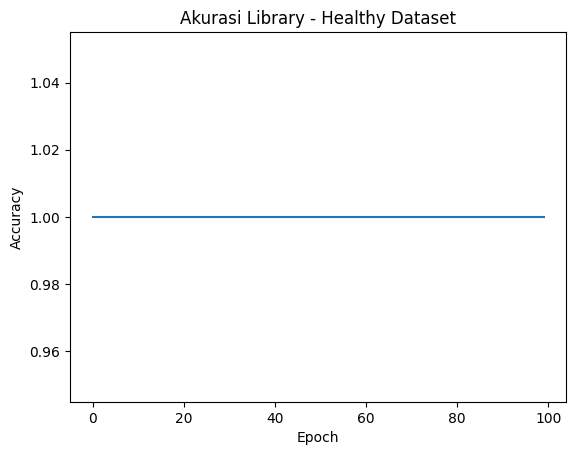

In [11]:
import tensorflow as tf
import numpy as np

# 1. Preprocessing & Normalisasi (Sangat penting untuk Keras)
X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# 2. Definisi Arsitektur Perceptron
model_healthy = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(X.shape[1],))
])

# 3. Kompilasi Model
model_healthy.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Training
history_healthy = model_healthy.fit(X_norm, y, epochs=100, verbose=0)

# 5. Evaluasi
loss, acc = model_healthy.evaluate(X_norm, y, verbose=0)
print(f"Hasil Library Keras -> Accuracy: {acc:.4f}, Loss: {loss:.4f}")

# 6. Plot Grafik Akurasi
plt.plot(history_healthy.history['accuracy'])
plt.title("Akurasi Library - Healthy Dataset")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

#### 2. Cari literatur tentang libary keras dalam membuat modul perceptron

Definisi Perceptron dalam Keras dalam literatur Keras, Perceptron tidak disebut sebagai objek "Perceptron" secara khusus, melainkan direpresentasikan sebagai sebuah Dense Layer (lapisan padat) dengan hanya 1 unit neuron.
*   Dense Layer: Adalah lapisan di mana setiap input terhubung sepenuhnya (fully connected) ke output.
*   Rumus Matematika: Keras menjalankan operasi vektor $y = f(X \cdot W + b)$, di mana $W$ adalah weight, $b$ adalah bias, dan $f$ adalah fungsi aktivasi.


---


Komponen Utama Arsitektur Keras untuk membuat Single Perceptron, literatur Keras menekankan tiga komponen utama:
*   tf.keras.Sequential: Ini adalah API yang digunakan untuk menyusun stack (tumpukan) lapisan secara linear. Karena ini Single Perceptron, kita hanya memasukkan satu lapisan saja.
*   layers.Dense(units=1): Angka 1 mendefinisikan bahwa ini adalah Perceptron tunggal.
*   input_shape: Ini mendefinisikan jumlah fitur (kolom) dari dataset. Tanpa mendefinisikan ini di awal, Keras tidak akan tahu berapa jumlah bobot (weights) yang harus dibuat sampai data pertama dimasukkan.


---


Fungsi Aktivasi, Perceptron klasik menggunakan Step Function. Namun, dalam implementasi Keras modern, digunakan:
*   Sigmoid: Mengubah output menjadi rentang 0 hingga 1. Ini sering dianggap sebagai versi "halus" dari Perceptron yang memungkinkan perhitungan gradien untuk proses belajar.
*   Hard Sigmoid: Terkadang digunakan jika ingin mendekati perilaku Perceptron asli yang lebih kaku.


---


Optimizer dan Loss Function, Ini adalah bagian "otak" yang melakukan pembaruan bobot secara otomatis:
*   Binary Crossentropy: Literatur menyebutkan ini sebagai fungsi kerugian (loss) standar untuk klasifikasi dua kelas. Ia mengukur seberapa jauh prediksi model dari label aslinya.
*   Adam/SGD (Stochastic Gradient Descent): Jika pada cara manual kita melakukan w = w + lr * error * x, Keras menggunakan algoritma optimasi seperti Adam yang secara matematis jauh lebih canggih dalam mengatur Learning Rate agar konvergensi (titik error terendah) tercapai lebih cepat.









#### 3. Bandingkan arsitektur coding tanpa libary dan dengan library, analisis dan buat dokumentasi

Definisi Struktur Model
*   Manual: Struktur dibangun secara prosedural. Kamu harus menulis logika matematika satu per satu menggunakan perulangan (for loop) untuk memproses setiap baris data.
*   Library: Struktur bersifat deklaratif. Kamu cukup mendefinisikan objek Dense(1) dan Keras secara otomatis membangun jaringan saraf di latar belakang.


---


Manajemen Bobot dan Bias
*   Manual: Bobot (w) dan bias (b) harus dibuat manual sebagai list atau array. Kamu juga harus mengatur nilai awalnya sendiri.
*   Library: Inisialisasi bobot terjadi secara otomatis menggunakan algoritma standar industri (seperti Glorot Uniform) yang membantu model belajar lebih stabil sejak awal.


---


Proses Prediksi (Forward Pass)
*   Manual: Menggunakan perkalian manual antara input dan bobot, lalu ditambahkan bias, dan diakhiri dengan fungsi if-else sederhana sebagai aktivasi.
*   Library: Menggunakan operasi matriks yang dioptimalkan. Perhitungan dilakukan serentak (paralel), sehingga jauh lebih cepat untuk data dalam jumlah besar.


---


Mekanisme Belajar (Weight Update)
*   Manual: Menggunakan rumus koreksi sederhana: "Bobot Baru = Bobot Lama + (Error * Input * Learning Rate)".
*   Library: Menggunakan algoritma optimasi canggih seperti Adam. Algoritma ini bisa mempercepat atau memperlambat kecepatan belajar secara otomatis berdasarkan tingkat kesulitan data.


---


Fungsi Aktivasi
*   Manual: Terbatas pada fungsi yang kamu tulis kodenya (biasanya hanya fungsi undak/step function 0 atau 1).
*   Library: Sangat fleksibel. Kamu bisa dengan mudah mengganti antara sigmoid, tanh, atau relu hanya dengan mengubah satu kata dalam kode.







#### 4. Cari dataset dari kaggle yang cocok untuk digunakan dalam ekperimen single perceptron, buat eksperimen dengan data tersebut

Link dataset: https://allisonhorst.github.io/palmerpenguins/

Tanpa Library

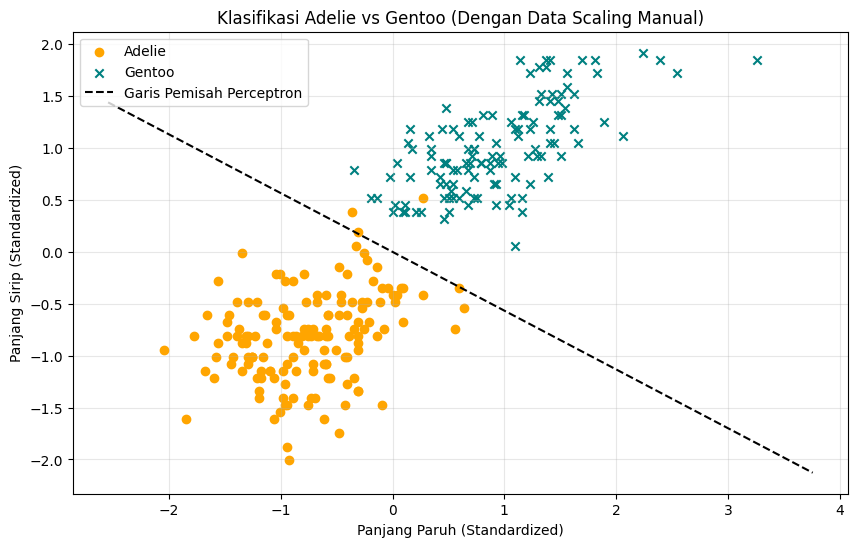

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PERSIAPAN DATA
penguins = sns.load_dataset('penguins')
penguins = penguins.dropna(subset=['bill_length_mm', 'flipper_length_mm', 'species'])
df_filtered = penguins[penguins['species'].isin(['Adelie', 'Gentoo'])]

X = df_filtered[['bill_length_mm', 'flipper_length_mm']].values
y = np.where(df_filtered['species'] == 'Adelie', -1, 1)

# ==========================================
# STANDARDISASI MANUAL TANPA SKLEARN
# ==========================================
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X = (X - mean) / std

# 2. KELAS PERCEPTRON
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = 1 if linear_output >= 0 else -1

                update = self.lr * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, -1)

# 3. TRAINING MODEL
model = Perceptron(learning_rate=0.1, n_iters=100)
model.fit(X, y)

# 4. VISUALISASI
plt.figure(figsize=(10, 6))

plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='orange', marker='o', label='Adelie')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='teal', marker='x', label='Gentoo')

x0_1 = np.amin(X[:, 0]) - 0.5
x0_2 = np.amax(X[:, 0]) + 0.5

x1_1 = (-model.weights[0] * x0_1 - model.bias) / model.weights[1]
x1_2 = (-model.weights[0] * x0_2 - model.bias) / model.weights[1]

plt.plot([x0_1, x0_2], [x1_1, x1_2], 'k--', label='Garis Pemisah Perceptron')

plt.xlabel('Panjang Paruh (Standardized)')
plt.ylabel('Panjang Sirip (Standardized)')
plt.title('Klasifikasi Adelie vs Gentoo (Dengan Data Scaling Manual)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


Dengan Library

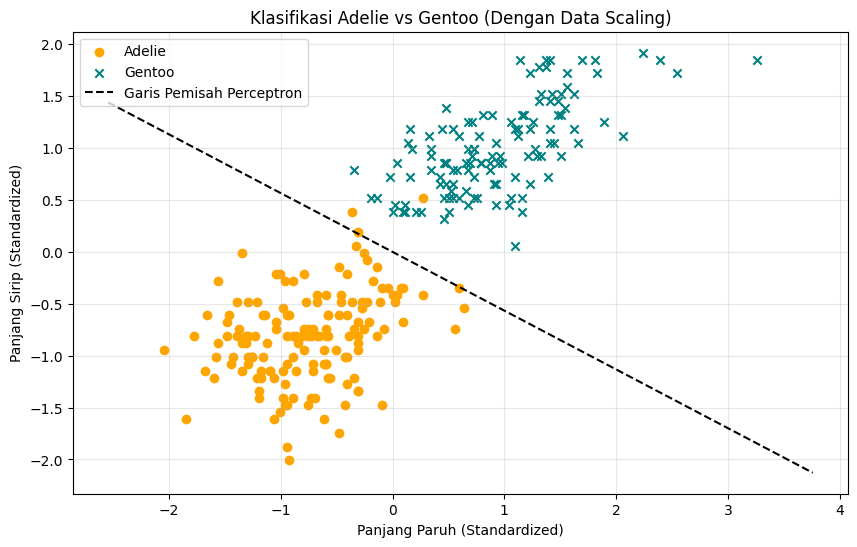

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler # <--- Library baru untuk scaling

# 1. PERSIAPAN DATA
penguins = sns.load_dataset('penguins')
penguins = penguins.dropna(subset=['bill_length_mm', 'flipper_length_mm', 'species'])
df_filtered = penguins[penguins['species'].isin(['Adelie', 'Gentoo'])]

X = df_filtered[['bill_length_mm', 'flipper_length_mm']].values
y = np.where(df_filtered['species'] == 'Adelie', -1, 1)

# ==========================================
# FITUR BARU: STANDARDISASI DATA
# ==========================================
scaler = StandardScaler()
X = scaler.fit_transform(X)
# Sekarang nilai X berada di kisaran angka kecil seperti -2, -1, 0, 1, 2

# 2. KELAS PERCEPTRON
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = 1 if linear_output >= 0 else -1

                update = self.lr * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, -1)

# 3. TRAINING MODEL
model = Perceptron(learning_rate=0.1, n_iters=100)
model.fit(X, y)

# 4. VISUALISASI
plt.figure(figsize=(10, 6))

plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='orange', marker='o', label='Adelie')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='teal', marker='x', label='Gentoo')

x0_1 = np.amin(X[:, 0]) - 0.5
x0_2 = np.amax(X[:, 0]) + 0.5

x1_1 = (-model.weights[0] * x0_1 - model.bias) / model.weights[1]
x1_2 = (-model.weights[0] * x0_2 - model.bias) / model.weights[1]

plt.plot([x0_1, x0_2], [x1_1, x1_2], 'k--', label='Garis Pemisah Perceptron')

# Perhatikan label sumbu sekarang berubah karena data sudah dinormalkan
plt.xlabel('Panjang Paruh (Standardized)')
plt.ylabel('Panjang Sirip (Standardized)')
plt.title('Klasifikasi Adelie vs Gentoo (Dengan Data Scaling)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()